# Setting up the enviroment

In [1]:
!python -m spacy download en_core_web_lg
!pip install spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import spacy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import spatial
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import nltk

nlp = spacy.load("en_core_web_lg")

Load Texts

In [3]:
import gdown

url = 'https://drive.google.com/drive/folders/18iqG9l7tvJs9LpCLeWWEgs1YsgJr2feP'
gdown.download_folder(url)

Retrieving folder contents


Processing file 1MwOZZLF44CgUpL7rJ8mJtZOxsfmfGnCx achristmascarol.txt
Processing file 1oXptAGOLnwSuNnEE6l80sJLR-IfIuQ-O alicesadventuresinwonderland.txt
Processing file 1tmi03qwlVbc7mVMEtwSFudoXwpu8Bmu9 annakarenina.txt
Processing file 1kIkIgOfz63r0iSeT2RI4Z-QwrwCv44gC astudyinscarlet.txt
Processing file 1NvOlntowfyJR1S38XbCAUdZXBFm4qJh0 ataleoftwocities.txt
Processing file 1vee7dkXZF1g7FsG0bcYTc35LMKPR7Dpy crimeandpunishment.txt
Processing file 1pbxgrk4RWsCWaTtJO1LRBLhMFCAJ81sV davidcopperfield.txt
Processing file 1yow_yxVECAItLmEgXUp4fbtXVjV7Owq_ dracula.txt
Processing file 1UhpUwYDdh0pMmP2bDa4-lKlFZ0qZA5ii edgarallanpoe.txt
Processing file 1LFxIKUDyiwmmPOaXBRHvWcO9fapSsDtE emma.txt
Processing file 1UBh9au0wThGDw8DMzYxoPL4BWrpQpm_T frankenstein.txt
Processing file 1rIJMXfFCqUx7k_QqN-Ipk_9AJvCZqEk0 greatexpectations.txt
Processing file 1shnAJxulIxdTkJE17cvop7R-rkMCtRtx grimmsfairytales.txt
Processing file 10hPrDVKImtmUoa5DN1UD17Z2Yiz6J9HP huckleberryfinn.txt
Processing file 1TapRKAI7m

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1MwOZZLF44CgUpL7rJ8mJtZOxsfmfGnCx
To: /content/Texts/achristmascarol.txt
100%|██████████| 182k/182k [00:00<00:00, 88.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oXptAGOLnwSuNnEE6l80sJLR-IfIuQ-O
To: /content/Texts/alicesadventuresinwonderland.txt
100%|██████████| 174k/174k [00:00<00:00, 50.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tmi03qwlVbc7mVMEtwSFudoXwpu8Bmu9
To: /content/Texts/annakarenina.txt
100%|██████████| 2.07M/2.07M [00:00<00:00, 61.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kIkIgOfz63r0iSeT2RI4Z-QwrwCv44gC
To: /content/Texts/astudyinscarlet.txt
100%|██████████| 269k/269k [00:00<00:00, 38.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NvOlntowfyJR1S38XbCAUdZXBFm4qJh0
To: /content/Texts/ataleoftwocities.txt
100%|██████████| 807k/807k [00:00<00:00, 78.0MB/s]
Do

['/content/Texts/achristmascarol.txt',
 '/content/Texts/alicesadventuresinwonderland.txt',
 '/content/Texts/annakarenina.txt',
 '/content/Texts/astudyinscarlet.txt',
 '/content/Texts/ataleoftwocities.txt',
 '/content/Texts/crimeandpunishment.txt',
 '/content/Texts/davidcopperfield.txt',
 '/content/Texts/dracula.txt',
 '/content/Texts/edgarallanpoe.txt',
 '/content/Texts/emma.txt',
 '/content/Texts/frankenstein.txt',
 '/content/Texts/greatexpectations.txt',
 '/content/Texts/grimmsfairytales.txt',
 '/content/Texts/huckleberryfinn.txt',
 '/content/Texts/janeeyre.txt',
 '/content/Texts/jekyllandhyde.txt',
 '/content/Texts/kingjamesbible.txt',
 '/content/Texts/lesmiserables.txt',
 '/content/Texts/littlewomen.txt',
 '/content/Texts/madamebovary.txt',
 '/content/Texts/mansfieldpark.txt',
 '/content/Texts/middlemarch.txt',
 '/content/Texts/mobydick.txt',
 '/content/Texts/northandsouth.txt',
 '/content/Texts/northangerabbey.txt',
 '/content/Texts/olivertwist.txt',
 '/content/Texts/persuasion.tx

# Getting Bias Axis

In [4]:
# From Practicum 6 solutions

gender_pairs = [
    ("girl", "boy"),
    ("queen", "king"),
    ("she", "he"),
    ("her", "his"),
    ("woman", "man"),
    ("herself", "himself"),
    ("daughter", "son"),
    ("mother", "father"),
    ("gal", "guy"),
    ("girl", "boy"),
]
female_words, male_words = zip(*gender_pairs)

gender_vectors = [
    nlp(f_word).vector - nlp(m_word).vector
    for f_word, m_word in gender_pairs
]
gender_axis = np.mean(gender_vectors, axis=0)

male_projections = [np.dot(nlp(w).vector, gender_axis) for w in male_words]
p_male = np.mean(male_projections)

female_projections = [np.dot(nlp(w).vector, gender_axis) for w in female_words]
p_female = np.mean(female_projections)

p_mid = (p_female + p_male) / 2
p_diff = p_female - p_male

known_bias = {}  # save calculated biases in dict to avoid re-calculating

# Gender bias over individual works

In [5]:
# Takes in words as a string and outputs a array of each words bias
nltk.download('stopwords')
nltk.download('punkt_tab')

def getBiasList(text, rm_stop_words = False, rm_punct = True):
  text = text.lower()

  tokens = word_tokenize(text)

  stop_words = set(stopwords.words('english'))
  punctuation = set(string.punctuation)

  content_words = tokens

  if rm_stop_words or rm_punct:
    content_words = [word for word in tokens if
                    (not rm_stop_words or word not in stop_words) and
                    (not rm_punct or word not in punctuation)]

  count = 0
  text_len = len(content_words)
  bias = np.zeros(text_len)

  new_bias = 0;

  for word in content_words:
    if word not in known_bias:
      p_word = np.dot(nlp(word).vector, gender_axis)
      bias_score = 2 * (p_word - p_mid) / (p_diff)
      known_bias[word] = bias_score
      bias[count] = bias_score
      new_bias+=1
    else:
      bias[count] = known_bias[word]

    if count % 10000 == 0 and new_bias > 0:
      print(f"{count/text_len * 100:.3f}% ({new_bias} new words indexed)")
      new_bias = 0;

    count += 1

  return bias

def getTokenList(text, rm_stop_words = False, rm_punct = True):
  text = text.lower()

  tokens = word_tokenize(text)

  stop_words = set(stopwords.words('english'))
  punctuation = set(string.punctuation)

  content_words = tokens

  if rm_stop_words or rm_punct:
    content_words = [word for word in tokens if
                    (not rm_stop_words or word not in stop_words) and
                    (not rm_punct or word not in punctuation)]

  return content_words

# bias = getBiasList("Texts/dracula.txt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


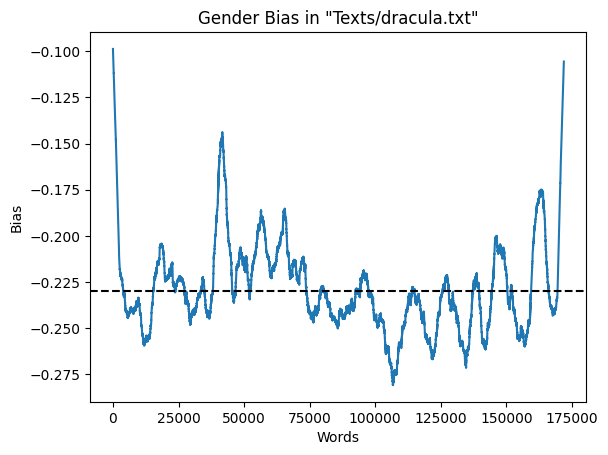

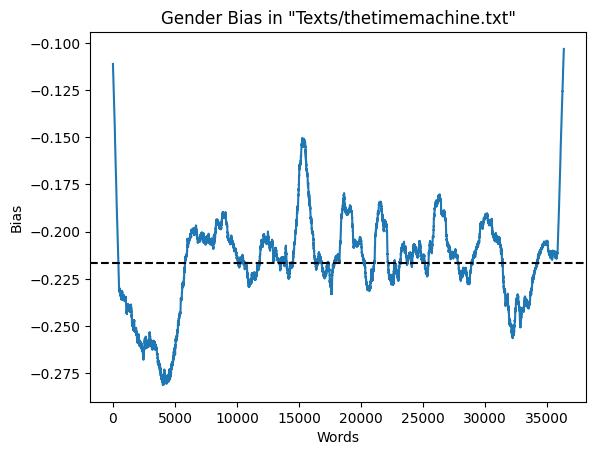

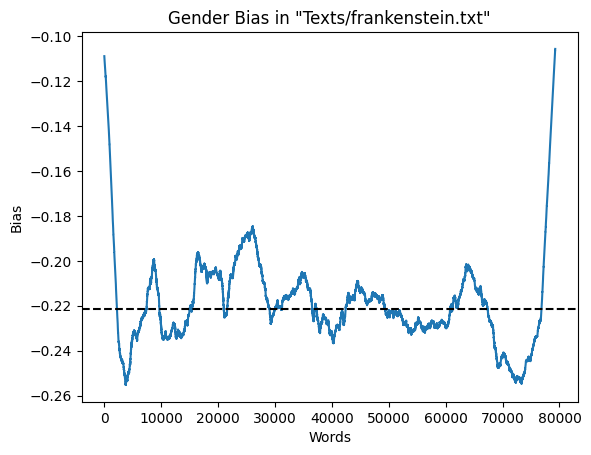

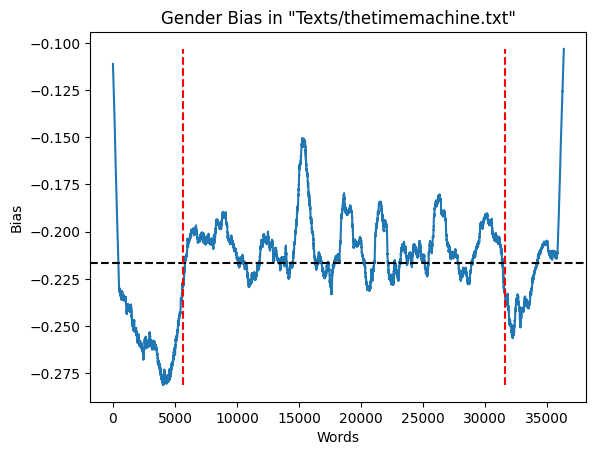

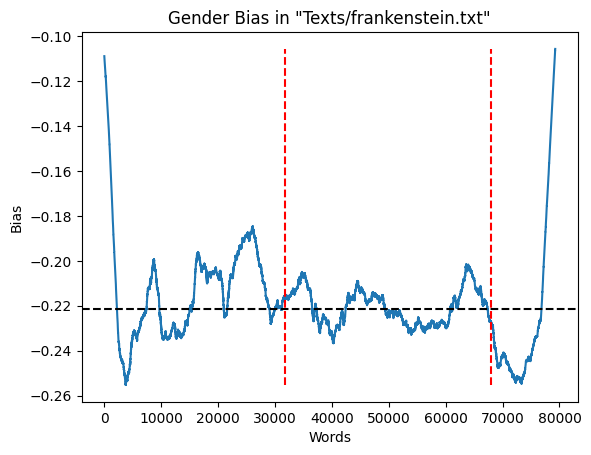

In [7]:
# gets indices of all instances of keyword
def getKeywordIndices(text, keywords, rm_stop_words = False, rm_punct = True):
  words = getTokenList(text, rm_stop_words = rm_stop_words, rm_punct = rm_punct)

  indices = []

  for i in range(len(words) - len(keywords) + 1):
    key_match = True
    for j in range(len(keywords)):
      if words[i + j] != keywords[j].lower():
        key_match = False
        break;
    if(key_match):
      indices.append(i)

  return indices

  # print(np.where(words == keyword))
  # return np.where(words == keyword)


def plotBias(filename, smooth_window = 0, keywordGroups = [], rm_stop_words = False, rm_punct = True):
  bias = 0
  with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()
    bias = getBiasList(text, rm_stop_words = rm_stop_words, rm_punct = rm_punct)

  if smooth_window > 0:
    kern = np.ones(smooth_window) / smooth_window
    y = np.convolve(bias, kern, mode = 'same')
  else:
    y = bias
  x = range(len(y))

  mean_value = np.mean(bias)
  mean_y = np.mean(y)
  range_y = np.max(y) - np.min(y)
  min_y = np.min(y)
  max_y = np.max(y)

  plt.plot(x, y)
  plt.axhline(y=mean_value, color = 'black', linestyle='--')

  for keywordGroup in keywordGroups:
    if len(keywordGroup) > 0:
      keywords = getKeywordIndices(text, keywordGroup.split(), rm_stop_words = rm_stop_words, rm_punct = rm_punct)
      plt.vlines(x=keywords, ymin=min_y, ymax=max_y, colors='red', linestyles='--')

  plt.title(f"Gender Bias in \"{filename}\"")
  plt.xlabel("Words")
  plt.ylabel("Bias")
  plt.show()

plotBias("Texts/dracula.txt", 5000)
plotBias("Texts/thetimemachine.txt", 1000)
plotBias("Texts/frankenstein.txt", 5000)
plotBias("Texts/thetimemachine.txt", 1000, ["face IV","story XVI"])
# plotBias("Texts/prideandprejudice.txt", 5000)
# plotBias("Texts/kingjamesbible.txt", 10000)
plotBias("Texts/frankenstein.txt", 5000, ["tale chapter 11","chapter 24 my"])

# Gender bias across multiple texts

In [ ]:
# Get texts from csv
df = pd.read_csv('Texts/Texts.csv')

textBiases = {}

def loadTextBiases(rm_stop_words = False, rm_punct = True):
  for row in df.itertuples(index=False):
      print(f"{row.Title} ({row.Year}) - {row.filename}")
      novelDict = {}
      novelDict["title"] = row.Title
      novelDict["year"] = row.Year
      novelDict["author"] = row.Author
      novelDict["gender"] = row.Gender

      genres = row.Genre.split(",")
      for i in range(len(genres)):
        genres[i] = genres[i].strip()
      novelDict["genres"] = genres

      with open(f"Texts/{row.filename}", 'r', encoding='utf-8') as f:
        biasList = getBiasList(f.read(), rm_stop_words = rm_stop_words, rm_punct = rm_punct)
        mean_bias = np.mean(biasList)
        std_bias = np.std(biasList)
        novelDict["bias"] = mean_bias
        novelDict["std"] = std_bias

      textBiases[row.filename] = novelDict

Pride and Prejudice (1813) - prideandprejudice.txt
Jane Eyre (1847) - janeeyre.txt
The Picture of Dorian Gray (1890) - thepictureofdoriangray.txt
Wuthering Heights (1847) - wutheringheights.txt
Crime and Punishment (1866) - crimeandpunishment.txt
Frankenstein (1818) - frankenstein.txt
The Count of Monte Cristo (1846) - thecountofmontecristo.txt
Alice's Adventures in Wonderland (1865) - alicesadventuresinwonderland.txt
Dracula (1897) - dracula.txt
Little Women (1868) - littlewomen.txt
Emma (1816) - emma.txt
Les Misérables (1862) - lesmiserables.txt
Persuasion (1818) - persuasion.txt
Anna Karenina (1878) - annakarenina.txt
The Adventures of Huckleberry Finn (1885) - huckleberryfinn.txt
Sense and Sensibility (1811) - senseandsensibility.txt
A Tale of Two Cities (1859) - ataleoftwocities.txt
Great Expectations (1861) - greatexpectations.txt
A Christmas Carol (1843) - achristmascarol.txt
The Brothers Karamazov (1880) - thebrotherskaramazov.txt
War and Peace (1869) - warandpeace.txt
The Adve

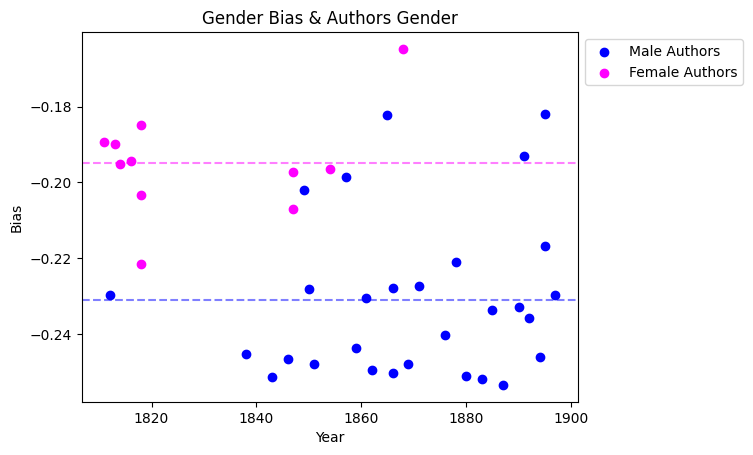

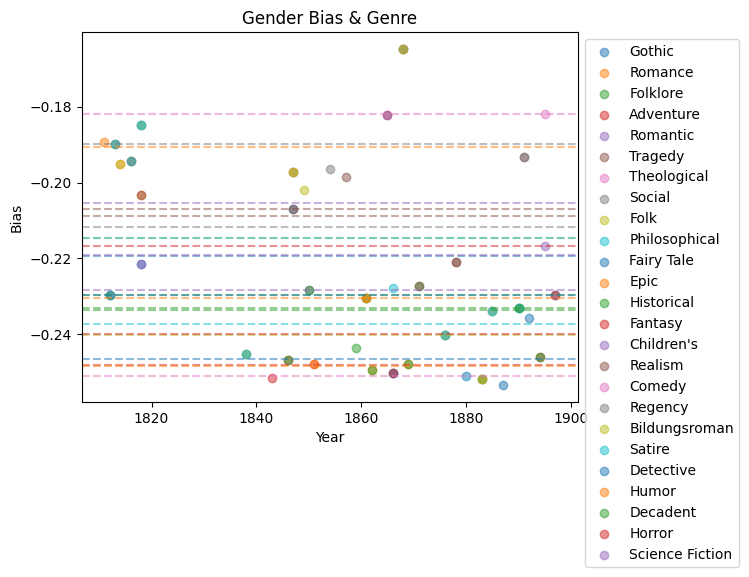

In [ ]:
# Plot gender & bias (over time)
def plotGenderBiases():
  xm = []
  ym = []
  merr = []

  xw = []
  yw = []
  werr = []

  for key in textBiases:
    if textBiases[key]["gender"] == "M":
      xm.append(textBiases[key]["year"])
      ym.append(textBiases[key]["bias"])
      merr.append(textBiases[key]["std"])
    else:
      xw.append(textBiases[key]["year"])
      yw.append(textBiases[key]["bias"])
      werr.append(textBiases[key]["std"])

  sc = plt.scatter(xm, ym, color = "blue", label = "Male Authors")
  color = sc.get_facecolor()[0]
  avg_bias = np.mean(ym)
  plt.axhline(y=avg_bias, color=color, linestyle='--', alpha=0.5)

  sc = plt.scatter(xw, yw, color = "magenta", label = "Female Authors")
  color = sc.get_facecolor()[0]
  avg_bias = np.mean(yw)
  plt.axhline(y=avg_bias, color=color, linestyle='--', alpha=0.5)

  plt.title(f"Gender Bias & Authors Gender")
  plt.xlabel("Year")
  plt.ylabel("Bias")
  plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
  plt.show()


def plotGenreBiases(minFreq = 0):
  genres = []

  for key in textBiases:
    for genre in textBiases[key]["genres"]:
      genres.append(genre)

  genres = list(set(genres))
  for genre in genres:
    gx = []
    gy = []
    count = 0
    for key in textBiases:
      if genre in textBiases[key]["genres"]:
        count += 1
        gx.append(textBiases[key]["year"])
        gy.append(textBiases[key]["bias"])

    if(count >= minFreq):
      sc = plt.scatter(gx, gy, label = genre, alpha=0.5)
      color = sc.get_facecolor()[0]
      avg_bias = np.mean(gy)
      plt.axhline(y=avg_bias, color=color, linestyle='--', alpha=0.5)


  plt.title(f"Gender Bias & Genre")
  plt.xlabel("Year")
  plt.ylabel("Bias")
  # plt.legend(loc='right')
  plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
  plt.show()


loadTextBiases(rm_stop_words = False, rm_punct = True)
plotGenderBiases()
plotGenreBiases(1)

# Analysis of music over time

Load music

In [ ]:
import gdown

url = 'https://drive.google.com/drive/folders/19MVBEtFYdvN52t2Bt67rXb6ckiLw7JoB'
gdown.download_folder(url)

Retrieving folder contents


Processing file 1HpAwplyLliZY_v-5mKVq7LevCGKHeA-Y 1946.txt
Processing file 1JdGJn8Z1uawRNSXbQ6jnlTFoH3QRdqkO 1950.txt
Processing file 1PYKBf-bNa2toJ2lhrQ-5SK8O-8-6gfto 1960.txt
Processing file 1ja4HKtKJa9BPKjZAZrZc4V9lzkNAi-tx 1970.txt
Processing file 112gRWoWNAqHosjFzzV3U5nZoPBQ8fZJF 1980.txt
Processing file 1i6N0pnSLk5gt_kevnN3umyx2IQLgE3eN 1990.txt
Processing file 1Bz9gzIKV_kGPNzVIrNqZ_7Pl66kaUJSL 2000.txt
Processing file 1Tb5kDsrh6jX7_6ciB0CpDBR7I-WJOf9r 2010.txt
Processing file 185YjeLRE4mphcRyP6HBR7Jaw9Nw4P-GU 2020.txt
Processing file 1cJ_KLq9LIcDbru4GYkBw42LxqEZSXdo9 2025.txt
Processing file 1XAlZmhxDF2IUFzM5J61n6Jml8t2xhFkK gender.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1HpAwplyLliZY_v-5mKVq7LevCGKHeA-Y
To: /content/Songs/1946.txt
100%|██████████| 7.91k/7.91k [00:00<00:00, 18.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JdGJn8Z1uawRNSXbQ6jnlTFoH3QRdqkO
To: /content/Songs/1950.txt
100%|██████████| 11.8k/11.8k [00:00<00:00, 26.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PYKBf-bNa2toJ2lhrQ-5SK8O-8-6gfto
To: /content/Songs/1960.txt
100%|██████████| 8.07k/8.07k [00:00<00:00, 18.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ja4HKtKJa9BPKjZAZrZc4V9lzkNAi-tx
To: /content/Songs/1970.txt
100%|██████████| 12.4k/12.4k [00:00<00:00, 21.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=112gRWoWNAqHosjFzzV3U5nZoPBQ8fZJF
To: /content/Songs/1980.txt
100%|██████████| 11.8k/11.8k [00:00<00:00, 22.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1i6N0pnS

['/content/Songs/1946.txt',
 '/content/Songs/1950.txt',
 '/content/Songs/1960.txt',
 '/content/Songs/1970.txt',
 '/content/Songs/1980.txt',
 '/content/Songs/1990.txt',
 '/content/Songs/2000.txt',
 '/content/Songs/2010.txt',
 '/content/Songs/2020.txt',
 '/content/Songs/2025.txt',
 '/content/Songs/gender.csv']

Get song biases

In [ ]:
years = [1946, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2025]

song_biases = {}

def loadSongBiases(rm_stop_words = False, rm_punct = False):
  for year in years:
    print(year)
    with open(f"Songs/{str(year)}.txt", 'r', encoding='utf-8') as f:
      contents = f.read()
      songs = contents.split("\n\n")
      biases = []
      for song in songs:
        biases.append(getBiasList(song, rm_stop_words = rm_stop_words, rm_punct = rm_punct))
        # biases.append(getSongBias(song))
      song_biases[year] = biases



1946
1950
0.000% (1 new words indexed)
0.000% (1 new words indexed)
1960
0.000% (1 new words indexed)
1970
1980
1990
2000
2010
0.000% (1 new words indexed)
2020
0.000% (1 new words indexed)
2025
0.000% (1 new words indexed)


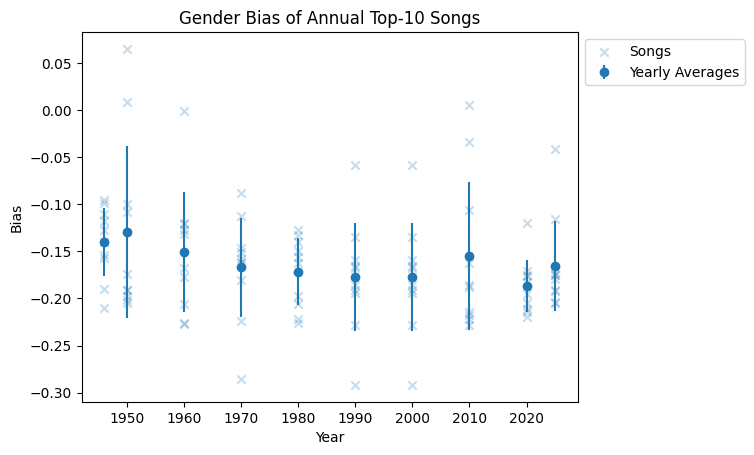

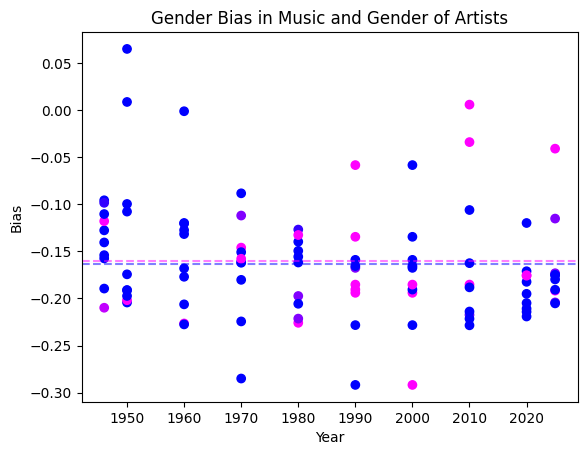

In [ ]:
def plotSongBiases():
  x_avg = []
  y_avg = []
  y_err = []
  x_songs = []
  y_songs = []

  for year in years:
    year_biases = []
    for song_bias in song_biases[year]:
      song_mean = np.mean(song_bias)
      year_biases.append(song_mean)
      x_songs.append(year)
      y_songs.append(song_mean)
    y_avg.append(np.mean(year_biases))
    x_avg.append(year)
    y_err.append(np.std(year_biases))

  plt.errorbar(x_avg, y_avg, yerr = y_err, label = "Yearly Averages", fmt = 'o')
  plt.scatter(x_songs, y_songs, alpha=0.25, marker = 'x', label = "Songs")

  plt.title(f"Gender Bias of Annual Top-10 Songs")
  plt.xlabel("Year")
  plt.ylabel("Bias")
  plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
  plt.show()

def plotSongGenderBias():
  csv = pd.read_csv('Songs/gender.csv')

  artist_gender = {}

  for row in csv.itertuples(index=False):
      gender_list = []
      for i in range(len(row)-1):
        gender_list.append(row[i+1])
      artist_gender[row.Year] = gender_list

  x = []
  y = []
  c = []

  msum = 0
  mweight = 0
  wsum = 0
  wweight = 0

  for year in years:
    for i in range(len(song_biases[year])):
      mean = np.mean(song_biases[year][i])
      x.append(year)
      y.append(mean)
      interp = (artist_gender[year][i] + 1)/2
      c.append(interp)

      wsum += interp * mean
      wweight += interp
      msum += (1-interp) * mean
      mweight += (1-interp)

  colors = ["blue", "magenta"]
  cmap_name = "bm"
  cm = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
  plt.scatter(x, y, c=c, cmap=cm)
  plt.axhline(y=msum/mweight, color="blue", linestyle='--', alpha=0.5)
  plt.axhline(y=wsum/wweight, color="magenta", linestyle='--', alpha=0.5)

  plt.title(f"Gender Bias in Music and Gender of Artists")
  plt.xlabel("Year")
  plt.ylabel("Bias")
  plt.show()


loadSongBiases(rm_stop_words = True, rm_punct = False)
plotSongBiases()

plotSongGenderBias()

In [ ]:
sorted_keys = sorted(known_bias, key=known_bias.get)

# first 50
top_50 = sorted_keys[-50:]

for k in top_50:
    print(k, known_bias[k])

pregnancy 1.0271424
women 1.0272377
gowns 1.0302494
dresses 1.0380105
petite 1.0420069
gals 1.0483164
hostess 1.0514565
squirting 1.0589156
aunty 1.0595219
gorgeous 1.0614568
dress 1.0619481
lipstick 1.0630183
maid 1.0659566
teen 1.0700834
babes 1.0722117
songstress 1.0749557
bridesmaids 1.0790635
gown 1.0803143
bridal 1.0828089
voluptuous 1.0836252
glamour 1.0929033
girls 1.093317
sultry 1.0944228
schoolgirl 1.0974126
her 1.1031988
nude 1.1043856
plumper 1.1090435
chick 1.1118548
heroine 1.1136118
buxom 1.1180742
pussy 1.1238794
sexy 1.1257274
vixen 1.134325
corset 1.1492994
brides 1.1567305
stockings 1.1590179
girl 1.1945752
herself 1.1974015
actresses 1.2034382
gal 1.2218183
goddess 1.2298007
housewife 1.2303894
pregnant 1.2381246
breasts 1.2531122
slut 1.2832861
babe 1.3422356
blonde 1.388234
lingerie 1.4083847
actress 1.4688475
brunette 1.5248832
